In [1]:
import matplotlib.pyplot as plt
from algorithms.tss_file import TSSFile
import os
from algorithms.wfm_edge import WFM_edge
from algorithms.tf_correction import get_fall_time

In [2]:
def find_file(filename, search_dir):
    for root, dirs, files in os.walk(search_dir):
        if filename in files:
            return root
    return None

In [3]:
folder = r'Y:\TESTDATA\DP\2025\12'
tss_file1 = 'Tek20251211T143833.tss'
path1 = find_file(tss_file1, folder)
tss1 = TSSFile(path1, tss_file1, source='Local')

tss_file2 = 'Tek20251211T143411.tss'
path2 = find_file(tss_file2, folder)
tss2 = TSSFile(path1, tss_file2, source='Local')

tss_file3 = 'Tek20251211T143001.tss'
path3 = find_file(tss_file3, folder)
tss3 = TSSFile(path1, tss_file3, source='Local')

channel_labels = tss1.channel_labels
num = len(channel_labels.keys())
print(channel_labels)

{'ch1': 'Vg', 'ch2': 'Vgi', 'ch3': 'Vd', 'ch4': 'Is', 'ch5': 'MC_GATE', 'ch8': 'Ig'}


In [4]:
def get_time(time, vd):
    vd_edges = WFM_edge(vd, time, falling_edge_number=2, 
                            rising_edge_number=2, 
                            peak_width=1,
                            peak_distance=10, 
                            sigma=25,
                            margin_ratio=20,)

    time_thresh_1 = 20
    time_thresh_2 = 80
    vd_f1 = vd_edges.get_edge(2, 'falling', time_thresh_2)['time']
    edge = vd_edges.get_edge(2, 'falling', time_thresh_1)
    vd_f2_results = get_fall_time(vd, time, 25, edge, vd_edges)
    vd_f2 = vd_f2_results['time']

    vd_r1 = vd_edges.get_edge(1, 'rising', time_thresh_1)['time']
    vd_r2 = vd_edges.get_edge(1, 'rising', time_thresh_2)['time']

    return vd_f1, vd_f2, vd_r1, vd_r2

In [5]:
time1 = tss1.waveforms[list(channel_labels.keys())[0]].time_for_frame()*1e9
time2 = tss2.waveforms[list(channel_labels.keys())[0]].time_for_frame()*1e9
time3 = tss3.waveforms[list(channel_labels.keys())[0]].time_for_frame()*1e9

vd1 = tss1.waveforms['ch3'].values_for_frame(0)
vd_f1a, vd_f2a, vd_r1a, vd_r2a = get_time(time1, vd1)

vd2 = tss2.waveforms['ch3'].values_for_frame(0)
vd_f1b, vd_f2b, vd_r1b, vd_r2b = get_time(time2, vd2)

vd3 = tss3.waveforms['ch3'].values_for_frame(0)
vd_f1c, vd_f2c, vd_r1c, vd_r2c = get_time(time3, vd3)

4.219468206468264
4.1320028399181865
4.198816614494376


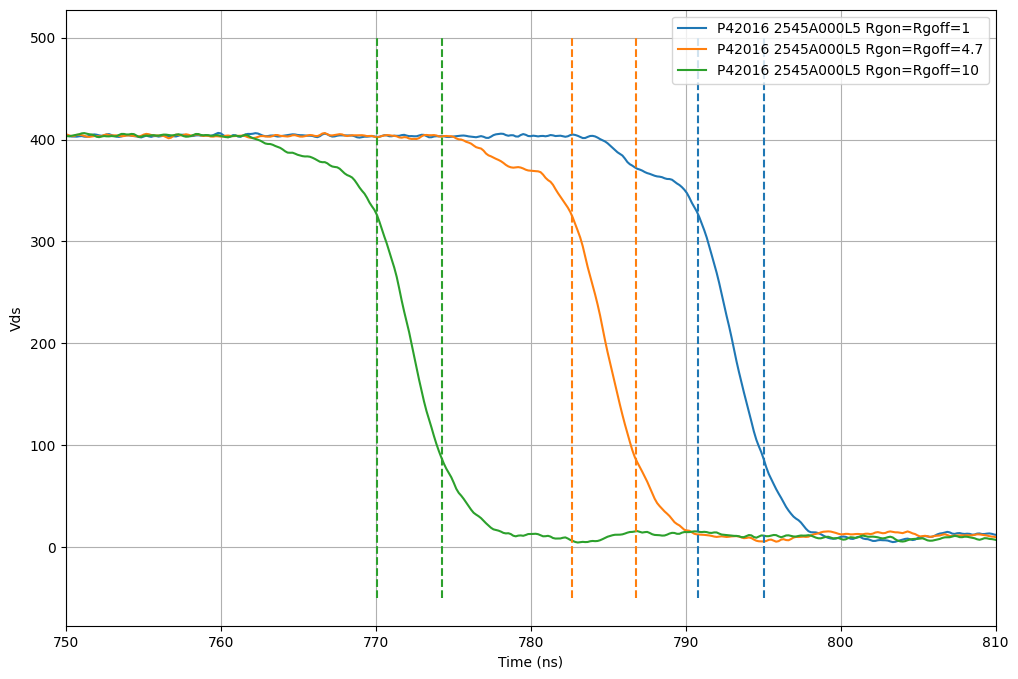

In [6]:
plt.figure(figsize=(12, 8))
plt.plot(time1, vd1, label='P42016 2545A000L5 Rgon=Rgoff=1')
plt.plot(time2, vd2, label='P42016 2545A000L5 Rgon=Rgoff=4.7')
plt.plot(time3, vd3, label='P42016 2545A000L5 Rgon=Rgoff=10')
plt.vlines(vd_f1a, -50, 500, linestyle='--', color='#1f77b4')
plt.vlines(vd_f2a, -50, 500, linestyle='--', color='#1f77b4')
plt.vlines(vd_f1b, -50, 500, linestyle='--', color='#ff7f0e')
plt.vlines(vd_f2b, -50, 500, linestyle='--', color='#ff7f0e')
plt.vlines(vd_f1c, -50, 500, linestyle='--', color='#2ca02c')
plt.vlines(vd_f2c, -50, 500, linestyle='--', color='#2ca02c')
plt.ylabel('Vds')
plt.grid(True)

print((vd_f2a - vd_f1a))
print((vd_f2b - vd_f1b))
print((vd_f2c - vd_f1c))
plt.legend()
plt.xlabel('Time (ns)')
plt.xlim([750, 810])
#plt.legend(loc='best')
plt.show()